In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import torch
from scipy.optimize import curve_fit

In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(repo_root))

import src.util as util

In [3]:
matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams.update({'font.size': 24})

In [4]:
h = 4.13567e-15
c = 3e8

path = repo_root / "paper_data"
results = []
N_runs = 5
for i in range(N_runs):
    res = np.load(path / f"fig1_N_sweeps_results_run_{i}.npz", allow_pickle=True)
    results.append(res)

params = np.load(path / "fig1_N_sweeps_params.npy", allow_pickle=True).item()
sweep_arrs = np.load(path / "fig1_N_sweeps_sweep_arrays.npy", allow_pickle=True).item()

energy = float(params["central_energy_ev"])  # eV
wvl = h * c / energy

mat = "au"
membrane_mat = "si3n4"
material_map = util.create_material_map(mat)
membrane_map = util.create_material_map(membrane_mat)
n = util.refractive_index_at_wvl(torch.tensor(wvl), material_map)
n_membrane = util.refractive_index_at_wvl(torch.tensor(wvl), membrane_map)

elem_thickness = float(params["element_thickness"])
membrane_thickness = float(params["membrane_thickness"])

In [5]:
Nelems = sweep_arrs["Nelems"]

In [6]:
materials = sweep_arrs["materials"]

In [7]:
opt_efficiencies = np.zeros((N_runs, len(materials), Nelems.shape[0]))
fill_factors_runs = np.zeros((N_runs, len(materials), Nelems.shape[0]))

for run_idx, res in enumerate(results):
    opt_efficiencies[run_idx] = res["opt_efficiencies"]
    fill_factors_runs[run_idx] = res["fill_factors"]

opt_efficiencies_mean = np.mean(opt_efficiencies, axis=0)
fill_factors = np.mean(fill_factors_runs, axis=0)

def eta_model(N, scale, k):
    return scale * (1 - np.exp(-k * N))

fit_N = Nelems[:3].astype(float)
learning_rates = np.zeros(len(materials))

for mat_idx in range(len(materials)):
    fit_eff = opt_efficiencies_mean[mat_idx, :3]
    p0 = [float(np.max(fit_eff)), 0.1]
    popt, _ = curve_fit(
        eta_model,
        fit_N,
        fit_eff,
        p0=p0,
        bounds=([0.0, 0.0], [2.0, np.inf]),
        maxfev=10000,
    )
    learning_rates[mat_idx] = popt[1]

print("fit k values:", learning_rates)

total_trans_params_arrs = []
for mat_idx, mat in enumerate(materials):
    n_mat = util.refractive_index_at_wvl(torch.tensor(wvl), util.create_material_map(mat))
    alpha_eff = 4 * np.pi / wvl * (
        n_membrane.imag.numpy() * membrane_thickness
        + fill_factors[mat_idx] * n_mat.imag.numpy() * elem_thickness
    )

    total_trans = np.exp(-alpha_eff * Nelems)
    eta = 1 - np.exp(-learning_rates[mat_idx] * Nelems)
    total_trans_params_arrs.append(eta * total_trans)

fit k values: [0.03894471 0.01536713 0.00760683 0.00251284]


In [8]:
ni_color = (212/255, 81/255, 44/255)
ge_color = (np.float64(0.4), np.float64(0.6509803921568628), np.float64(0.11764705882352941), np.float64(1.0))
si_color = (114/255, 29/255, 194/255)

colors = ['tab:blue', ni_color, ge_color, si_color]

In [9]:
total_trans_params_arrs_norm = [arr / np.max(np.array(total_trans_params_arrs)) for arr in total_trans_params_arrs]

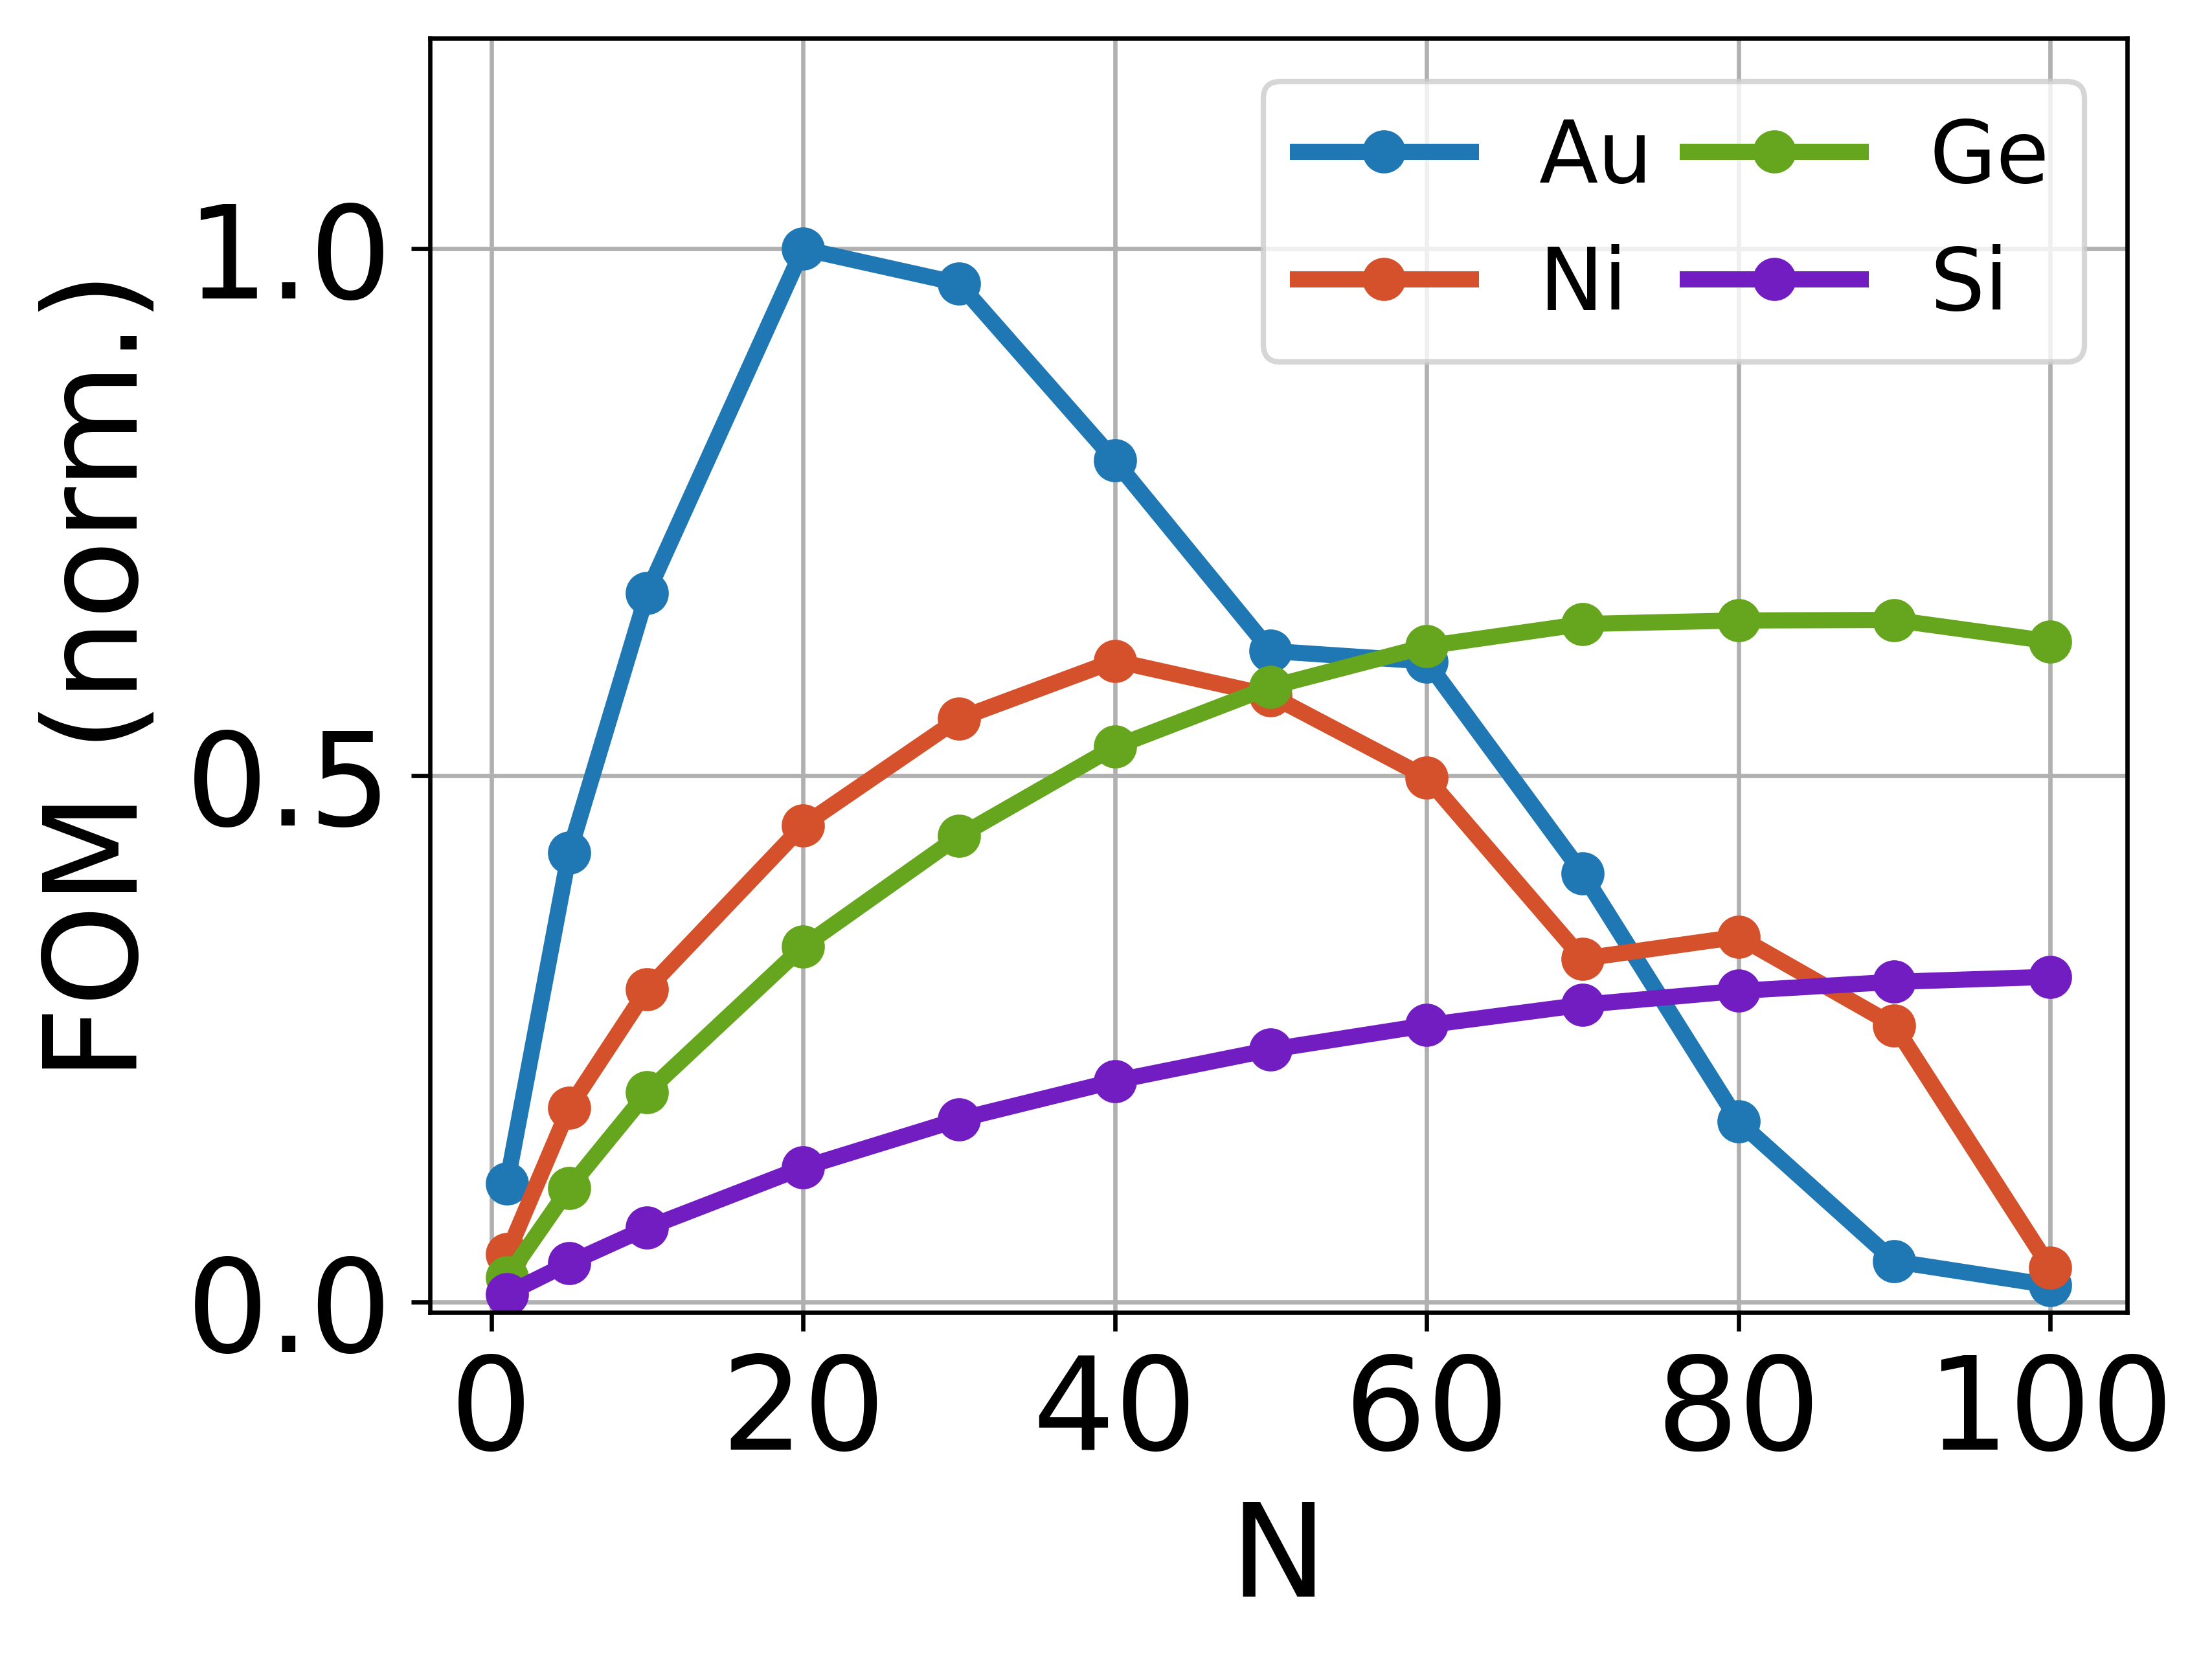

In [10]:
Nticks = [0, 20, 40, 60, 80, 100]
for i, mat in enumerate(materials):
    plt.plot(Nelems, total_trans_params_arrs_norm[i], linewidth=3, marker='o', markersize=7, label=mat.capitalize(), color=colors[i])

plt.xlabel("N", fontsize=24)
plt.ylabel("FOM (norm.)", fontsize=24)
plt.xticks(ticks=Nticks, fontsize=24)
plt.yticks(fontsize=24)
plt.legend(fontsize=16, ncols=2, columnspacing=0.4, loc='upper right', )
plt.ylim(-0.01, 1.2)
plt.grid(True)
plt.tight_layout()
# plt.semilogy()
plt.show()